#### Analyze the mapping quality of E-MTAB-9536
- **Developed by:** Anna Maguza
- **Affilation:** Faculty of Medicine, Würzburg University
- **Created date:** 23th October 2024
- **Last modified dte:** 23th October 2024

This notebook is created to check the quality of the mapping from E-MTAB-9536 study. In this notebook we are visualizing `StarSolo` mapping metrics. 

+ Import packages

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import glob

+ Some samples had UMI length 12, and some ten, therefore the mapping script tried both options, and ended up in generation of two Log.progress.out files but one is empty. The following function intends to choose the correct file by analyzing file size.

In [2]:
def get_log_file(sample_dir):
    umi10_log = os.path.join(sample_dir, "UMI10_Log.progress.out")
    umi12_log = os.path.join(sample_dir, "UMI12_Log.progress.out")
    
    if os.path.exists(umi12_log) and os.path.getsize(umi12_log) > 1000:
        return umi12_log
    elif os.path.exists(umi10_log) and os.path.getsize(umi10_log) > 1000:
        return umi10_log
    else:
        return None

+ Transform Log.progress.out file to dataframe

In [3]:
def process_sample(sample_dir):
    log_file = get_log_file(sample_dir)
    if log_file is None:
        print(f"Warning: No valid mapping log found for sample {os.path.basename(sample_dir)}")
        return None
    
    try:
        # Read the file, skipping the header rows
        df = pd.read_csv(log_file, sep='\s+', skiprows=2,
                        names=['Month', 'Day', 'Time', 'Speed', 'Number', 'Length', 
                              'Mapped_unique', 'Mapped_length', 'Mapped_MMrate', 
                              'Mapped_multi', 'Unmapped_multi+', 'Unmapped_MM', 
                              'Unmapped_short', 'Unmapped_other'])
        
        # Convert percentage columns to float
        percentage_columns = ['Mapped_unique', 'Mapped_MMrate', 'Mapped_multi',
                            'Unmapped_multi+', 'Unmapped_MM', 'Unmapped_short', 
                            'Unmapped_other']
        
        for col in percentage_columns:
            df[col] = df[col].str.rstrip('%').astype('float') / 100.0
        
        # Convert numeric columns
        df['Mapped_length'] = pd.to_numeric(df['Mapped_length'])
        
        # Calculate means for the metrics of interest
        metrics_of_interest = ['Mapped_unique', 'Mapped_length', 'Mapped_MMrate',
                             'Mapped_multi', 'Unmapped_multi+', 'Unmapped_MM',
                             'Unmapped_short', 'Unmapped_other']
        
        mean_values = df[metrics_of_interest].mean()
        return mean_values
        
    except Exception as e:
        print(f"Error processing {log_file}: {str(e)}")
        return None

In [4]:
BASE_DIR = "raw_data/Elmentaite_2021/remapped_fetal_data_E-MTAB-9536_starsolo"

In [5]:
sample_dirs = glob.glob(os.path.join(BASE_DIR, "*"))
results = {}
for sample_dir in sample_dirs:
    sample_name = os.path.basename(sample_dir)
    print(f"Processing sample: {sample_name}")
        
    mean_values = process_sample(sample_dir)
    if mean_values is not None:
        results[sample_name] = mean_values

Processing sample: Human_colon_16S7985395
Processing sample: Human_colon_16S8159189
Processing sample: Human_colon_16S7985393
Processing sample: FCA_gut8015060
Processing sample: FCA_gut8015057
Processing sample: Human_colon_16S8159186
Processing sample: Human_colon_16S7985389
Processing sample: Human_colon_16S7985392
Processing sample: FCA_gut8015059
Processing sample: Human_colon_16S8159190
Processing sample: Human_colon_16S8159185
Processing sample: FCA_gut8015058
Processing sample: Human_colon_16S8159183
Processing sample: Human_colon_16S7985394
Processing sample: Human_colon_16S8159187
Processing sample: Human_colon_16S8159184
Processing sample: Human_colon_16S8159182
Processing sample: Human_colon_16S8159188
Processing sample: Human_colon_16S7985391
Processing sample: Human_colon_16S7985390
Processing sample: FCA_gut8015061


In [6]:
results_df = pd.DataFrame(results).T

In [7]:
results_df

,Mapped_unique,Mapped_length,Mapped_MMrate,Mapped_multi,Unmapped_multi+,Unmapped_MM,Unmapped_short,Unmapped_other
Human_colon_16S7985395,0.800977,86.818605,0.002000,0.153000,0.002000,0.0,0.034000,0.009674
Human_colon_16S8159189,0.717357,90.700000,0.002000,0.206786,0.009000,0.0,0.064500,0.002286
Human_colon_16S7985393,0.814872,89.717949,0.002000,0.149000,0.002000,0.0,0.028128,0.006000
FCA_gut8015060,0.624641,100.600000,0.002000,0.147872,0.015000,0.0,0.210103,0.002000
FCA_gut8015057,0.581900,100.500000,0.002000,0.169600,0.017000,0.0,0.229300,0.002000
Human_colon_16S8159186,0.714864,90.700000,0.002000,0.219909,0.010000,0.0,0.052955,0.002000
Human_colon_16S7985389,0.808865,89.900000,0.002000,0.153000,0.002000,0.0,0.031000,0.005000
Human_colon_16S7985392,0.806939,88.569388,0.002000,0.153000,0.002000,0.0,0.030939,0.007000
FCA_gut8015059,0.559545,100.500000,0.002000,0.156000,0.020000,0.0,0.261727,0.002000
Human_colon_16S8159190,0.666298,90.700000,0.002000,0.188872,0.016809,0.0,0.126298,0.002043


In [8]:
output_file = os.path.join(BASE_DIR, "mapping_metrics_summary.csv")
results_df.to_csv(output_file)

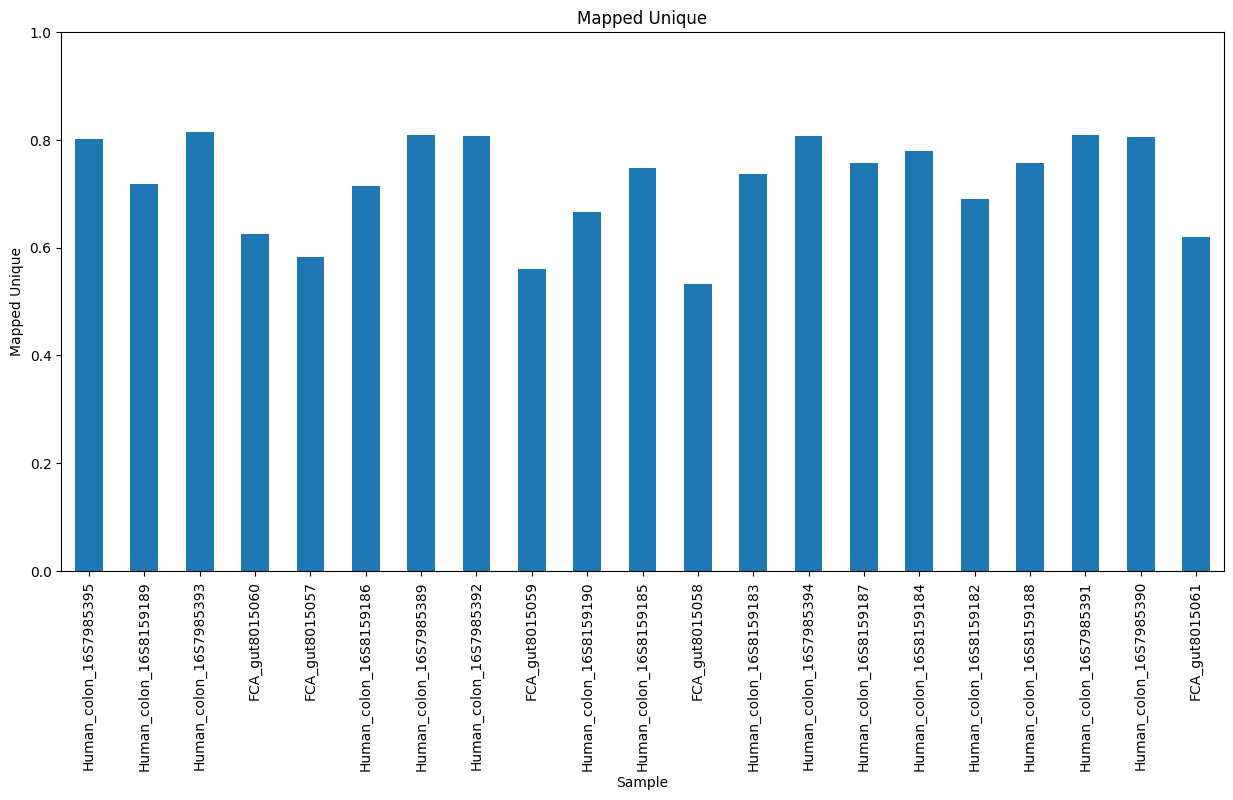

In [10]:
results_df['Mapped_unique'].plot(kind='bar', figsize=(15, 7), title='Mapped Unique')
plt.xlabel('Sample')
plt.ylabel('Mapped Unique')
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.show()